# AOS Correlation Explorer &mdash; Multi-Night

Same correlation hunt as `correlation_explorer.ipynb`, but pooled across many
nights so persistent mechanical/thermal effects separate from per-night
atmospheric regimes.

**Night selection:** we only keep nights whose **median `psf_fwhm` < `FWHM_LIMIT`**
(default 1.0"). Bad-seeing nights are dominated by the atmosphere and dilute the
mechanical signal we are after. The median is read cheaply by querying only the
`psf_fwhm` column from each parquet.

**Physics framing (unchanged, authoritative):**

- *Ultimate targets* to reduce: `psf_fwhm` and `psf_ellipticity_median`.
- `donut_blur_fwhm`, `dimm`, `airmass` are **atmospheric confounds** (not AOS-controllable).
- Partial correlation residualizes target + driver against those confounds, so the
  ranking surfaces mechanical/thermal leads rather than rediscovering "seeing drives PSF".

In [1]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Parameters ---
PARQUET_DIR = "../parquet_files"
FWHM_LIMIT = 1.0  # arcsec; keep nights with median psf_fwhm below this

files = sorted(glob.glob(os.path.join(PARQUET_DIR, "*.parquet")))
print(f"{len(files)} parquet files found")

INFO:numexpr.utils:Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.


INFO:numexpr.utils:Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.


INFO:numexpr.utils:NumExpr defaulting to 16 threads.


44 parquet files found


## 1. Select nights by median PSF FWHM

Fast pass: read **only** the `psf_fwhm` column from each file to get the night's
median. Unreadable / truncated files are reported and skipped.

In [2]:
def night_of(path):
    # nightly_aos_table_YYYYMMDD_summit.parquet
    return os.path.basename(path).split("_")[3]

summary, bad = [], []
for f in files:
    try:
        med = pd.read_parquet(f, columns=["psf_fwhm"])["psf_fwhm"].median()
        n = pd.read_parquet(f, columns=["psf_fwhm"]).shape[0]
        summary.append({"night": night_of(f), "path": f,
                        "median_psf_fwhm": float(med), "n": int(n)})
    except Exception as e:
        bad.append((night_of(f), type(e).__name__))

night_df = pd.DataFrame(summary).sort_values("night").reset_index(drop=True)
night_df["selected"] = night_df["median_psf_fwhm"] < FWHM_LIMIT

if bad:
    print(f"Skipped {len(bad)} unreadable file(s): {[b[0] for b in bad]}")
sel = night_df[night_df["selected"]]
print(f"{len(night_df)} readable nights; {len(sel)} pass median psf_fwhm < {FWHM_LIMIT}\"")
print(f"pooled exposures in selected nights: {int(sel['n'].sum())}")
night_df

Skipped 4 unreadable file(s): ['20260619', '20260705', '20260706', '20260709']
40 readable nights; 22 pass median psf_fwhm < 1.0"
pooled exposures in selected nights: 13692


,night,path,median_psf_fwhm,n,selected
0,20260329,../parquet_files/nightly_aos_table_20260329_su...,0.958002,798,True
1,20260404,../parquet_files/nightly_aos_table_20260404_su...,0.992121,545,True
2,20260408,../parquet_files/nightly_aos_table_20260408_su...,1.006965,854,False
3,20260412,../parquet_files/nightly_aos_table_20260412_su...,1.108949,754,False
4,20260415,../parquet_files/nightly_aos_table_20260415_su...,1.194955,620,False
5,20260418,../parquet_files/nightly_aos_table_20260418_su...,0.717674,318,True
6,20260419,../parquet_files/nightly_aos_table_20260419_su...,1.032390,634,False
7,20260420,../parquet_files/nightly_aos_table_20260420_su...,1.056630,664,False
8,20260421,../parquet_files/nightly_aos_table_20260421_su...,0.980242,737,True
9,20260423,../parquet_files/nightly_aos_table_20260423_su...,0.929831,706,True


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


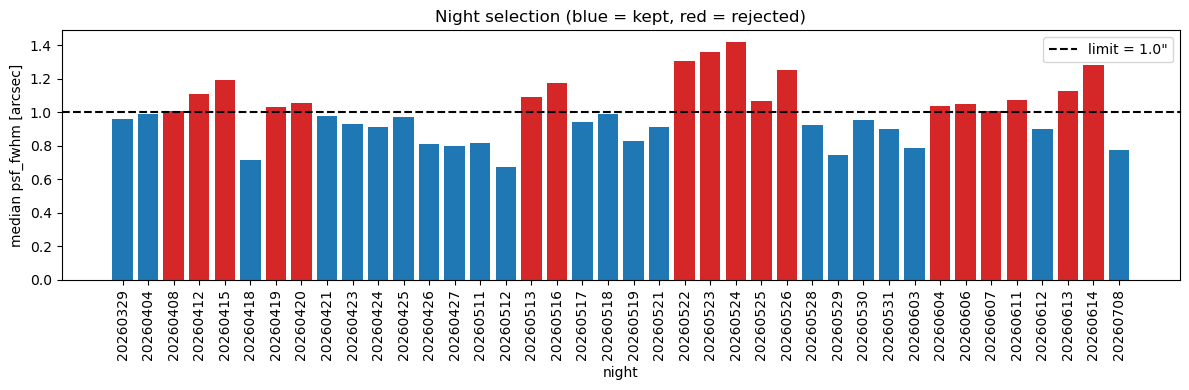

In [3]:
# Visualize the cut
fig, ax = plt.subplots(figsize=(12, 4))
colors = ["C0" if s else "C3" for s in night_df["selected"]]
ax.bar(night_df["night"], night_df["median_psf_fwhm"], color=colors)
ax.axhline(FWHM_LIMIT, ls="--", color="k", label=f"limit = {FWHM_LIMIT}\"")
ax.set_ylabel("median psf_fwhm [arcsec]")
ax.set_xlabel("night")
ax.set_title(f"Night selection (blue = kept, red = rejected)")
ax.tick_params(axis="x", rotation=90)
ax.legend()
fig.tight_layout()

## 2. Load and pool the selected nights

Concatenate the full tables for the selected nights, tagging each row with its
`night` so we can group/color later.

In [4]:
parts = []
for _, r in sel.iterrows():
    d = pd.read_parquet(r["path"])
    d["night"] = r["night"]
    parts.append(d)

raw = pd.concat(parts, ignore_index=True)
print(f"pooled: {len(raw)} exposures x {raw.shape[1]} cols from {len(parts)} nights")
print("band counts:")
print(raw["band"].value_counts())

pooled: 13692 exposures x 89 cols from 22 nights
band counts:
band
i_39    4601
y_10    2968
z_20    2258
r_57    2145
g_6     1079
u_24     641
Name: count, dtype: int64


## 3. Build a scalar feature table

Expand the physically-interpretable vector columns into scalars (same as the
single-night explorer):

- `zernikes_fwhm` (25) &rarr; `zkfwhm_z4 ... zkfwhm_z28` (arcsec FWHM contribution).
- `vmodes` (12) &rarr; `vmode_1 ... vmode_12` (AOS control eigen-modes).

In [5]:
def expand_vector(df, col, prefix, start=1):
    """Expand a fixed-length list column into scalar columns prefix{start..}."""
    sub = df[col].dropna()
    if len(sub) == 0:
        return pd.DataFrame(index=df.index)
    n = len(sub.iloc[0])
    mat = np.full((len(df), n), np.nan)
    mask = df[col].notna().values
    mat[mask] = np.vstack(sub.values)
    names = [f"{prefix}{i}" for i in range(start, start + n)]
    return pd.DataFrame(mat, columns=names, index=df.index)

zk = expand_vector(raw, "zernikes_fwhm", "zkfwhm_z", start=4)
vm = expand_vector(raw, "vmodes", "vmode_", start=1)

feat = pd.concat([raw.select_dtypes(include="number"), zk, vm,
                  raw[["night"]]], axis=1)
feat = feat.loc[:, ~feat.columns.duplicated()]
print("feature columns:", feat.shape[1])

feature columns: 96


## 4. Targets, confounds, candidate drivers

The raw ConsDB `z4..z28` columns are dropped as drivers: they are the same
quantity as `zkfwhm_z4..z28` up to a fixed per-Zernike factor, so they would
double up in the ranking. We keep the arcsec `zkfwhm_*` versions.

In [6]:
TARGETS = ["psf_fwhm", "fwhm_zenith_500nm", "psf_ellipticity_median"]

# Atmospheric / dome seeing: not AOS-controllable -> remove these.
CONFOUNDS = ["donut_blur_fwhm", "dimm", "airmass"]

_raw_zernikes = {f"z{i}" for i in range(4, 29)}
_exclude = set(TARGETS) | set(CONFOUNDS) | _raw_zernikes | {
    "visit_id", "day_obs", "seq", "detector", "__index_level_0__",
    # other image-quality metrics, not drivers of the targets
    "psf_fwhm_min", "psf_fwhm_max", "psf_fwhm_05", "psf_fwhm_95",
    "psf_fwhm_95_05", "psf_fwhm_sigma", "psf_ellipticity_sigma",
    "psf_area", "psf_area_min", "psf_area_max", "aos_fwhm",
}
DRIVERS = [c for c in feat.select_dtypes(include="number").columns
           if c not in _exclude and feat[c].notna().sum() > 50]
print(f"{len(DRIVERS)} candidate drivers")
print(DRIVERS)

53 candidate drivers
['air_temp', 'elevation', 'azimuth', 'rotation_angle', 'cam_air_temp', 'm2_air_temp', 'm1m3_air_temp', 'outside_temp', 'seq_num_corr', 'x_gradient', 'y_gradient', 'z_gradient', 'radial_gradient', 'm2_delta_t', 'dome_delta_t', 'cam_m1m3_delta_t', 'zkfwhm_z4', 'zkfwhm_z5', 'zkfwhm_z6', 'zkfwhm_z7', 'zkfwhm_z8', 'zkfwhm_z9', 'zkfwhm_z10', 'zkfwhm_z11', 'zkfwhm_z12', 'zkfwhm_z13', 'zkfwhm_z14', 'zkfwhm_z15', 'zkfwhm_z16', 'zkfwhm_z17', 'zkfwhm_z18', 'zkfwhm_z19', 'zkfwhm_z20', 'zkfwhm_z21', 'zkfwhm_z22', 'zkfwhm_z23', 'zkfwhm_z24', 'zkfwhm_z25', 'zkfwhm_z26', 'zkfwhm_z27', 'zkfwhm_z28', 'vmode_1', 'vmode_2', 'vmode_3', 'vmode_4', 'vmode_5', 'vmode_6', 'vmode_7', 'vmode_8', 'vmode_9', 'vmode_10', 'vmode_11', 'vmode_12']


## 5. Raw vs partial correlation, pooled across nights

`ranked_corr` gives the plain Spearman ranking (atmosphere still in). `partial_corr_table`
residualizes target and driver against the atmospheric confounds and reports both,
so shrinkage from raw&rarr;partial flags pure seeing proxies.

In [7]:
def ranked_corr(df, targets, drivers, method="spearman"):
    rows = []
    for t in targets:
        for d in drivers:
            s = df[[t, d]].dropna()
            if len(s) < 30 or s[d].std() == 0:
                continue
            r, p = (stats.spearmanr if method == "spearman" else stats.pearsonr)(s[t], s[d])
            rows.append((t, d, r, p, len(s)))
    out = pd.DataFrame(rows, columns=["target", "driver", "r", "p", "n"])
    out["abs_r"] = out["r"].abs()
    return out.sort_values("abs_r", ascending=False).reset_index(drop=True)

def residualize(y, X):
    """Residuals of y regressed on X (with intercept)."""
    X1 = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    return y - X1 @ beta

def partial_corr_table(df, targets, drivers, confounds, method="spearman"):
    rows = []
    for t in targets:
        for d in drivers:
            s = df[[t, d] + confounds].dropna()
            if len(s) < 30 or s[d].std() == 0:
                continue
            C = s[confounds].values
            ry = residualize(s[t].values, C)
            rd = residualize(s[d].values, C)
            corr = stats.spearmanr if method == "spearman" else stats.pearsonr
            pr, pp = corr(ry, rd)
            rr, _ = corr(s[t], s[d])
            rows.append((t, d, rr, pr, pp, len(s)))
    out = pd.DataFrame(rows, columns=["target", "driver", "raw_r", "partial_r", "p", "n"])
    out["abs_partial"] = out["partial_r"].abs()
    return out.sort_values("abs_partial", ascending=False).reset_index(drop=True)

raw_rank = ranked_corr(feat, TARGETS, DRIVERS + CONFOUNDS)
print("Top 20 raw correlations (confounds included):")
raw_rank.head(20)

Top 20 raw correlations (confounds included):


,target,driver,r,p,n,abs_r
0,psf_fwhm,donut_blur_fwhm,0.712378,0.000000e+00,13651,0.712378
1,fwhm_zenith_500nm,donut_blur_fwhm,0.696223,0.000000e+00,13651,0.696223
2,fwhm_zenith_500nm,dimm,0.491251,0.000000e+00,8185,0.491251
3,psf_fwhm,dimm,0.330615,5.486187e-208,8185,0.330615
4,psf_fwhm,airmass,0.316126,0.000000e+00,13660,0.316126
5,psf_fwhm,elevation,-0.314941,0.000000e+00,13660,0.314941
6,psf_ellipticity_median,donut_blur_fwhm,-0.268116,3.119009e-223,13639,0.268116
7,fwhm_zenith_500nm,zkfwhm_z24,-0.231834,4.194482e-166,13660,0.231834
8,psf_fwhm,zkfwhm_z26,-0.223600,2.334017e-154,13660,0.223600
9,psf_fwhm,zkfwhm_z24,-0.213565,1.128151e-140,13660,0.213565


In [8]:
pc = partial_corr_table(feat, TARGETS, DRIVERS, CONFOUNDS)
print("Top 25 partial correlations (atmosphere removed), pooled across nights:")
pc.head(25)

Top 25 partial correlations (atmosphere removed), pooled across nights:


,target,driver,raw_r,partial_r,p,n,abs_partial
0,psf_fwhm,cam_m1m3_delta_t,0.177770,0.292105,1.434450e-160,8177,0.292105
1,fwhm_zenith_500nm,cam_m1m3_delta_t,0.107299,0.279996,3.710072e-147,8177,0.279996
2,psf_fwhm,vmode_7,0.246386,0.263817,2.900612e-130,8177,0.263817
3,psf_fwhm,vmode_4,0.104633,0.257016,1.657260e-123,8177,0.257016
4,psf_fwhm,rotation_angle,0.112885,0.226500,1.259502e-95,8177,0.226500
5,psf_fwhm,zkfwhm_z4,-0.139771,-0.223613,3.427039e-93,8177,0.223613
6,psf_fwhm,vmode_12,-0.242834,-0.219035,2.121191e-89,8177,0.219035
7,psf_fwhm,vmode_11,-0.044860,-0.218048,1.358888e-88,8177,0.218048
8,fwhm_zenith_500nm,zkfwhm_z6,-0.110036,-0.217169,7.036366e-88,8177,0.217169
9,fwhm_zenith_500nm,vmode_7,0.151855,0.208140,1.014267e-80,8177,0.208140


### Drivers that survive de-seeing

In [9]:
survivors = pc[(pc["abs_partial"] > 0.15) & (pc["p"] < 0.01)].copy()
survivors["shrinkage"] = 1 - survivors["abs_partial"] / survivors["raw_r"].abs().clip(lower=1e-6)
print(f"{len(survivors)} (target, driver) pairs with |partial r| > 0.15 and p < 0.01")
survivors[["target", "driver", "raw_r", "partial_r", "p", "n"]].head(30)

43 (target, driver) pairs with |partial r| > 0.15 and p < 0.01


,target,driver,raw_r,partial_r,p,n
0,psf_fwhm,cam_m1m3_delta_t,0.177770,0.292105,1.434450e-160,8177
1,fwhm_zenith_500nm,cam_m1m3_delta_t,0.107299,0.279996,3.710072e-147,8177
2,psf_fwhm,vmode_7,0.246386,0.263817,2.900612e-130,8177
3,psf_fwhm,vmode_4,0.104633,0.257016,1.657260e-123,8177
4,psf_fwhm,rotation_angle,0.112885,0.226500,1.259502e-95,8177
5,psf_fwhm,zkfwhm_z4,-0.139771,-0.223613,3.427039e-93,8177
6,psf_fwhm,vmode_12,-0.242834,-0.219035,2.121191e-89,8177
7,psf_fwhm,vmode_11,-0.044860,-0.218048,1.358888e-88,8177
8,fwhm_zenith_500nm,zkfwhm_z6,-0.110036,-0.217169,7.036366e-88,8177
9,fwhm_zenith_500nm,vmode_7,0.151855,0.208140,1.014267e-80,8177


## 6. Diagnostic scatter plots for the strongest partial correlations

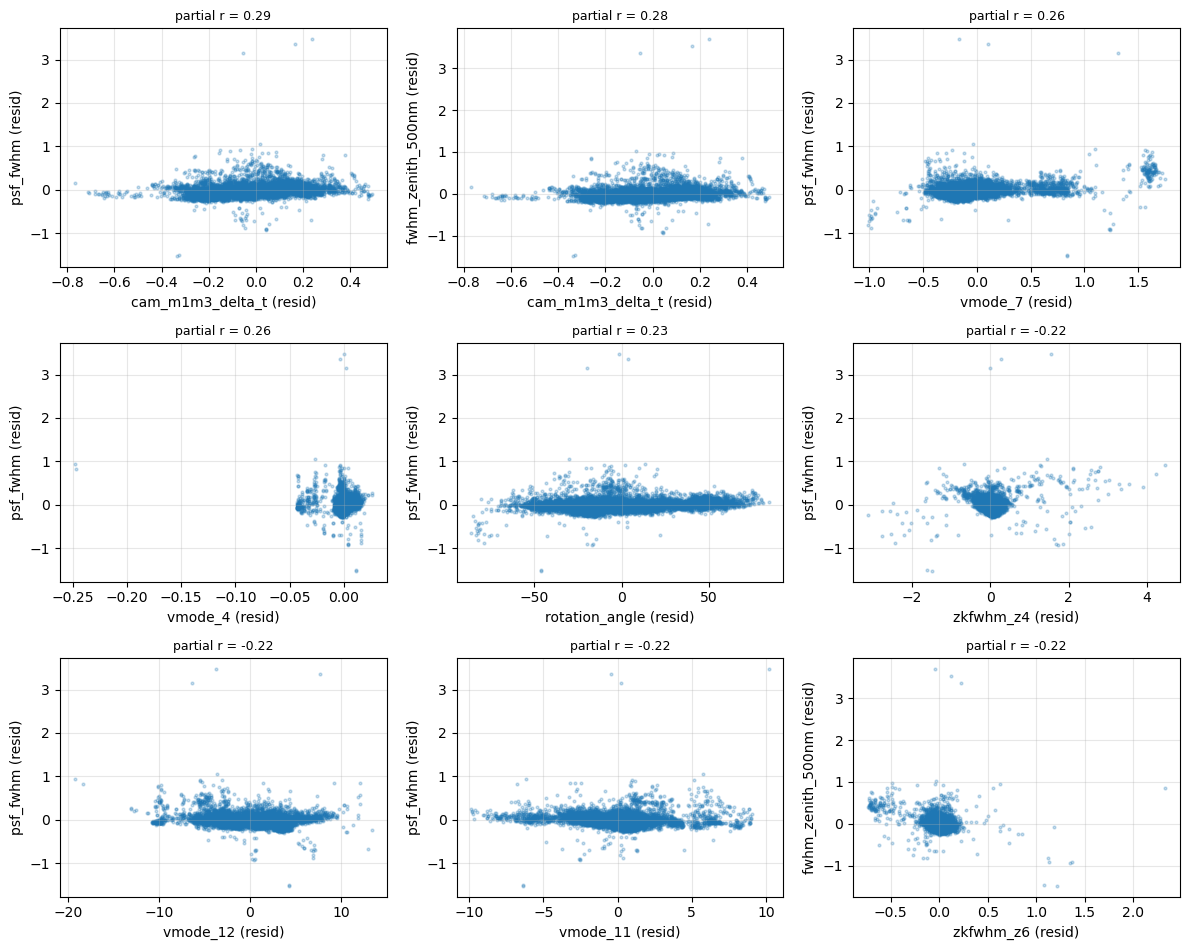

In [10]:
def scatter_partial(df, target, driver, confounds, ax):
    s = df[[target, driver] + confounds].dropna()
    C = s[confounds].values
    ry = residualize(s[target].values, C)
    rd = residualize(s[driver].values, C)
    ax.scatter(rd, ry, s=4, alpha=0.25)
    pr, _ = stats.spearmanr(ry, rd)
    ax.set_xlabel(f"{driver} (resid)")
    ax.set_ylabel(f"{target} (resid)")
    ax.set_title(f"partial r = {pr:.2f}", fontsize=9)
    ax.grid(alpha=0.3)

top = survivors.head(9)
if len(top):
    ncol = 3
    nrow = int(np.ceil(len(top) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, r) in zip(axes, top.iterrows()):
        scatter_partial(feat, r["target"], r["driver"], CONFOUNDS, ax)
    for ax in axes[len(top):]:
        ax.axis("off")
    fig.tight_layout()
else:
    print("No survivors to plot.")

## 7. Per-night stability of the top leads

A pooled correlation could be driven by a few nights. For the strongest drivers,
recompute the partial correlation **within each night** and show the spread.
A lead that is consistent across nights is far more trustworthy than one that
only appears in the pool.

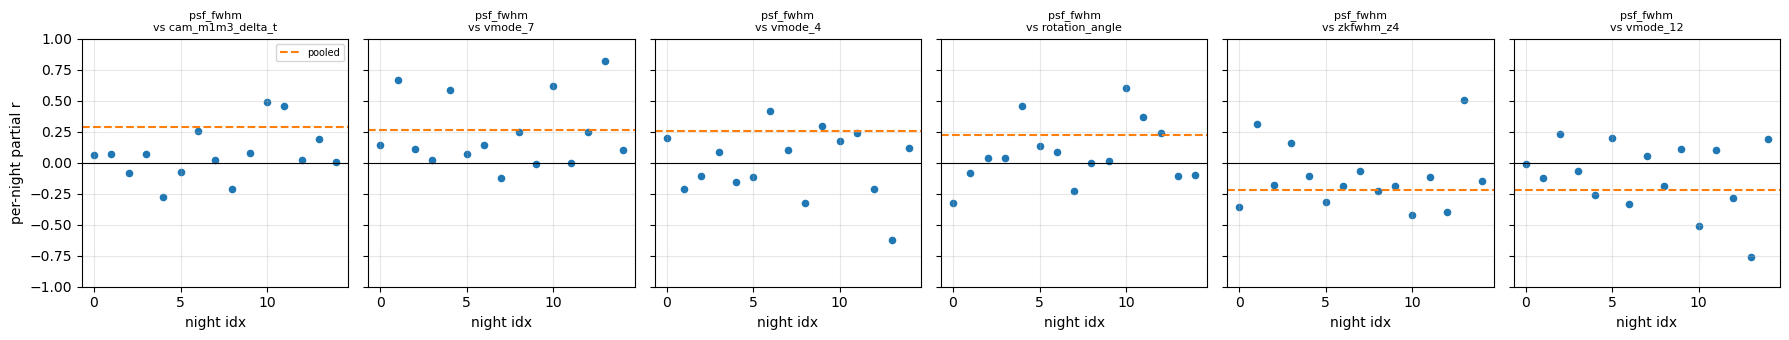

In [11]:
def per_night_partial(df, target, driver, confounds):
    out = []
    for night, g in df.groupby("night"):
        s = g[[target, driver] + confounds].dropna()
        if len(s) < 30 or s[driver].std() == 0:
            continue
        C = s[confounds].values
        ry = residualize(s[target].values, C)
        rd = residualize(s[driver].values, C)
        pr, _ = stats.spearmanr(ry, rd)
        out.append((night, pr, len(s)))
    return pd.DataFrame(out, columns=["night", "partial_r", "n"])

# Top distinct (target, driver) leads for psf_fwhm and ellipticity
leads = (survivors[survivors["target"].isin(["psf_fwhm", "psf_ellipticity_median"])]
         .drop_duplicates(subset=["target", "driver"]).head(6))

if len(leads):
    fig, axes = plt.subplots(1, len(leads), figsize=(3 * len(leads), 3.5), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, r) in zip(axes, leads.iterrows()):
        pn = per_night_partial(feat, r["target"], r["driver"], CONFOUNDS)
        ax.axhline(0, color="k", lw=0.8)
        ax.scatter(range(len(pn)), pn["partial_r"], s=20)
        ax.axhline(r["partial_r"], ls="--", color="C1", label="pooled")
        ax.set_title(f"{r['target']}\nvs {r['driver']}", fontsize=8)
        ax.set_xlabel("night idx")
        ax.set_ylim(-1, 1)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("per-night partial r")
    axes[0].legend(fontsize=7)
    fig.tight_layout()
else:
    print("No leads to check.")

## 8. Band split

The pool spans `u` through `y`. A wavelength-dependent effect can partly cancel
when bands are pooled, so here we rerun the partial-correlation ranking **within
each band** (grouping by the leading band character, e.g. `i_39` &rarr; `i`).

Bands with too few exposures are skipped. We then compare the partial correlation
of the pooled top leads across bands, so a driver that only bites in the blue (or
only in the red) stands out instead of being averaged away.

In [12]:
feat["band_char"] = raw["band"].str[0].values
band_counts = feat["band_char"].value_counts()
MIN_BAND_N = 300
bands = [b for b in band_counts.index if band_counts[b] >= MIN_BAND_N]
print("exposures per band:")
print(band_counts)
print(f"\nbands analysed (n >= {MIN_BAND_N}): {bands}")

exposures per band:
band_char
i    4601
y    2968
z    2258
r    2145
g    1079
u     641
Name: count, dtype: int64

bands analysed (n >= 300): ['i', 'y', 'z', 'r', 'g', 'u']


In [13]:
# Top partial-correlation leads within each band
per_band = {}
for b in bands:
    sub = feat[feat["band_char"] == b]
    per_band[b] = partial_corr_table(sub, TARGETS, DRIVERS, CONFOUNDS)

for b in bands:
    print(f"===== band {b}  (n={int(band_counts[b])}) : top 8 partial correlations =====")
    cols = ["target", "driver", "raw_r", "partial_r", "p", "n"]
    print(per_band[b][cols].head(8).to_string(index=False))
    print()

===== band i  (n=4601) : top 8 partial correlations =====
                target           driver     raw_r  partial_r            p    n
     fwhm_zenith_500nm       zkfwhm_z11 -0.158593  -0.310284 1.436886e-66 2937
              psf_fwhm       zkfwhm_z11 -0.132977  -0.302212 4.427346e-63 2937
     fwhm_zenith_500nm        zkfwhm_z6 -0.113446  -0.283256 2.575351e-55 2937
              psf_fwhm        zkfwhm_z6 -0.099361  -0.281029 1.924915e-54 2937
     fwhm_zenith_500nm          vmode_8 -0.162401  -0.235032 3.790236e-38 2937
psf_ellipticity_median          vmode_5 -0.216787  -0.233836 1.048305e-37 2932
              psf_fwhm          vmode_8 -0.164400  -0.233557 1.115646e-37 2937
     fwhm_zenith_500nm cam_m1m3_delta_t  0.065350   0.231419 5.261737e-37 2937

===== band y  (n=2968) : top 8 partial correlations =====
                target         driver     raw_r  partial_r            p    n
              psf_fwhm      zkfwhm_z4 -0.110482  -0.527581 6.904798e-97 1340
     fwhm_zenith_5

### Pooled top leads compared across bands

For each strong pooled lead, tabulate its per-band partial correlation. `NaN`
means the pair did not have enough data in that band. This is where a
wavelength-dependent lever (consistent sign/size in some bands, absent in others)
becomes visible.

In [14]:
lead_pairs = (survivors.drop_duplicates(subset=["target", "driver"])
              .head(12)[["target", "driver", "partial_r"]]
              .rename(columns={"partial_r": "pooled"}))

def band_lookup(b, target, driver):
    t = per_band[b]
    hit = t[(t["target"] == target) & (t["driver"] == driver)]
    return float(hit["partial_r"].iloc[0]) if len(hit) else np.nan

for b in bands:
    lead_pairs[b] = [band_lookup(b, t, d)
                     for t, d in zip(lead_pairs["target"], lead_pairs["driver"])]

pd.set_option("display.float_format", lambda x: f"{x:.2f}")
print("Partial r of pooled top leads, by band:")
lead_pairs.reset_index(drop=True)

Partial r of pooled top leads, by band:


,target,driver,pooled,i,y,z,r,g,u
0,psf_fwhm,cam_m1m3_delta_t,0.29,0.23,0.26,0.37,-0.00,0.09,0.01
1,fwhm_zenith_500nm,cam_m1m3_delta_t,0.28,0.23,0.28,0.39,0.00,0.07,0.02
2,psf_fwhm,vmode_7,0.26,0.14,0.19,0.23,0.08,-0.12,0.38
3,psf_fwhm,vmode_4,0.26,0.05,0.33,0.42,0.15,-0.09,0.10
4,psf_fwhm,rotation_angle,0.23,0.14,0.43,0.02,0.15,0.02,0.17
5,psf_fwhm,zkfwhm_z4,-0.22,-0.00,-0.53,-0.35,-0.32,0.14,-0.23
6,psf_fwhm,vmode_12,-0.22,-0.09,-0.29,-0.02,-0.17,-0.15,-0.05
7,psf_fwhm,vmode_11,-0.22,-0.05,-0.26,-0.58,0.09,0.28,-0.08
8,fwhm_zenith_500nm,zkfwhm_z6,-0.22,-0.28,-0.20,-0.21,-0.32,-0.08,-0.10
9,fwhm_zenith_500nm,vmode_7,0.21,0.15,0.19,0.19,0.10,-0.11,0.37


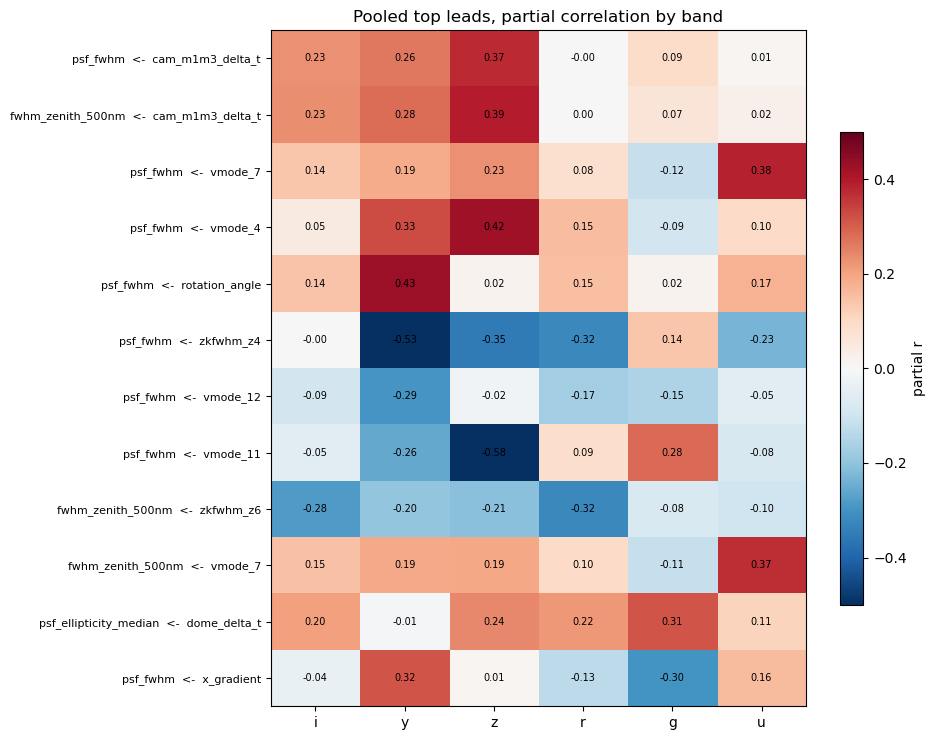

In [15]:
# Heatmap of the same table: pooled leads (rows) x band (cols)
mat = lead_pairs[bands].values.astype(float)
row_labels = [f"{t}  <-  {d}" for t, d in zip(lead_pairs["target"], lead_pairs["driver"])]
fig, ax = plt.subplots(figsize=(1.1 * len(bands) + 3, 0.5 * len(row_labels) + 1.5))
im = ax.imshow(mat, vmin=-0.5, vmax=0.5, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(len(bands))); ax.set_xticklabels(bands)
ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels, fontsize=8)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        if not np.isnan(mat[i, j]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.7, label="partial r")
ax.set_title("Pooled top leads, partial correlation by band")
fig.tight_layout()

## 9. Notes / next steps

- Compare the pooled leads here against the single-night findings in
  `correlation_explorer.ipynb`. Leads that persist across many good-seeing nights
  (see the per-night panel) are the strongest candidates for real, controllable
  effects.
- Leads pointing at variables **not yet in the parquet** (wind, dome vent state,
  mount tracking error) are signals to extend `nightly_tablemaker.ipynb`.
- Try tightening / loosening `FWHM_LIMIT`, or splitting by `band`, to see which
  effects are seeing-regime or wavelength dependent.